# Validation 03: Gordon16 / BEAST Dust Law

This notebook validates the JAX-CIGALE implementation of the Gordon et al. (2016) BEAST `R(V), f_A` extinction family.

The goal is not to fit a galaxy. The goal is narrower and more auditable:

1. compute the Gordon16 curve with an **independent NumPy/SciPy reference** following the BEAST equations;
2. compute the same curve with the JAX-CIGALE implementation;
3. compare both over wavelength and dust-parameter grids;
4. verify transmission and gradients are physically/numerically sane;
5. save plots and JSON metrics for external audit.


## 1. Imports and Output Directory

The notebook only needs JAX, NumPy, SciPy, and matplotlib. It does not need DSPS or FSPS.


In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

from sedinfer.experimental.jaxcigale.dependencies import require_jax
from sedinfer.experimental.jaxcigale.modules import (
    _gordon16_rvfa_a_over_av,
    _gordon16_rv_a_from_mixture_rv,
    _gordon16_mixture_rv_from_rv_a,
)

jax, jnp = require_jax()

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "sedinfer").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "validation" and (PROJECT_ROOT.parent.parent / "sedinfer").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

OUTPUT_DIR = Path("outputs/validation_gordon16_dust")
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = PROJECT_ROOT / OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("JAX default dtype:", np.asarray(jnp.asarray(1.0)).dtype)
print("Output directory:", OUTPUT_DIR)


Matplotlib is building the font cache; this may take a moment.


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX default dtype: float64
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/validation_gordon16_dust


## 2. Independent BEAST-Style Reference

These functions are intentionally duplicated here rather than imported from `sedinfer`. They follow the BEAST implementation structure:

- component A: Fitzpatrick99 Milky-Way-like curve;
- component B: Gordon03 SMC-Bar curve with fixed `R_V = 2.74`;
- Gordon16 mixture: `f_A * A + (1 - f_A) * B`;
- public `R_V` is the mixture value, so the Milky-Way component `R(V)_A` is derived internally.


In [2]:
RV_B_SMC_BAR = 2.74


def reference_rv_a_from_mixture_rv(rv, f_a):
    """BEAST/Gordon16 equation for the Milky-Way component R(V)_A."""
    if f_a <= 0.0:
        return 3.1
    return 1.0 / (1.0 / (rv * f_a) - (1.0 - f_a) / (f_a * RV_B_SMC_BAR))


def reference_mixture_rv_from_rv_a(rv_a, f_a):
    """Mixture R_V implied by component R(V)_A and f_A."""
    return 1.0 / (f_a / rv_a + (1.0 - f_a) / RV_B_SMC_BAR)


def reference_fitzpatrick99_a_over_av(wave_a, rv):
    """Independent NumPy/SciPy copy of BEAST's Fitzpatrick99 curve."""
    wave_a = np.asarray(wave_a, dtype=float)
    x = np.clip(1.0e4 / wave_a, 0.3, 10.0)

    c2 = -0.824 + 4.717 / rv
    c1 = 2.030 - 3.007 * c2
    c3 = 3.23
    c4 = 0.41
    x0 = 4.596
    gamma = 0.99
    xcutuv = 10000.0 / 2700.0
    xspluv = 10000.0 / np.array([2700.0, 2600.0])

    k = np.zeros_like(x)
    uv = x >= xcutuv
    k[uv] = c1 + c2 * x[uv] + c3 * x[uv] ** 2 / ((x[uv] ** 2 - x0**2) ** 2 + gamma**2 * x[uv] ** 2)
    yspluv = c1 + c2 * xspluv + c3 * xspluv**2 / ((xspluv**2 - x0**2) ** 2 + gamma**2 * xspluv**2)

    fuv = x >= 5.9
    k[fuv] += c4 * (0.5392 * (x[fuv] - 5.9) ** 2 + 0.05644 * (x[fuv] - 5.9) ** 3)
    k[uv] += rv
    yspluv += rv

    optical = x < xcutuv
    xsplopir = np.zeros(7)
    xsplopir[1:7] = 10000.0 / np.array([26500.0, 12200.0, 6000.0, 5470.0, 4670.0, 4110.0])
    ysplopir = np.zeros(7)
    ysplopir[0:3] = np.array([0.0, 0.26469, 0.82925]) * rv / 3.1
    ysplopir[3:7] = np.array([
        np.poly1d([2.13572e-04, 1.00270, -4.22809e-01])(rv),
        np.poly1d([-7.35778e-05, 1.00216, -5.13540e-02])(rv),
        np.poly1d([-3.32598e-05, 1.00184, 7.00127e-01])(rv),
        np.poly1d([1.19456, 1.01707, -5.46959e-03, 7.97809e-04, -4.45636e-05][::-1])(rv),
    ])
    spline = interpolate.splrep(np.hstack([xsplopir, xspluv]), np.hstack([ysplopir, yspluv]), k=3)
    k[optical] = interpolate.splev(x[optical], spline)
    return k / rv


def reference_gordon03_smcbar_a_over_av(wave_a):
    """Independent NumPy/SciPy copy of BEAST's Gordon03 SMC-Bar curve."""
    wave_a = np.asarray(wave_a, dtype=float)
    x = np.clip(1.0e4 / wave_a, 0.3, 10.0)

    rv = RV_B_SMC_BAR
    c1 = -4.959 / rv
    c2 = 2.264 / rv
    c3 = 0.389 / rv
    c4 = 0.461 / rv
    x0 = 4.6
    gamma = 1.0
    xcutuv = 10000.0 / 2700.0
    xspluv = 10000.0 / np.array([2700.0, 2600.0])

    k = np.zeros_like(x)
    uv = x >= xcutuv
    k[uv] = 1.0 + c1 + c2 * x[uv] + c3 * x[uv] ** 2 / ((x[uv] ** 2 - x0**2) ** 2 + gamma**2 * x[uv] ** 2)
    yspluv = 1.0 + c1 + c2 * xspluv + c3 * xspluv**2 / ((xspluv**2 - x0**2) ** 2 + gamma**2 * xspluv**2)

    fuv = x >= 5.9
    k[fuv] += c4 * (0.5392 * (x[fuv] - 5.9) ** 2 + 0.05644 * (x[fuv] - 5.9) ** 3)

    optical = x < xcutuv
    xsplopir = np.zeros(9)
    xsplopir[1:10] = 1.0 / np.array([2.198, 1.65, 1.25, 0.81, 0.65, 0.55, 0.44, 0.37])
    ysplopir = np.array([0.0, 0.11, 0.169, 0.25, 0.567, 0.801, 1.00, 1.374, 1.672])
    spline = interpolate.splrep(np.hstack([xsplopir, xspluv]), np.hstack([ysplopir, yspluv]), k=3)
    k[optical] = interpolate.splev(x[optical], spline)
    return k


def reference_gordon16_a_over_av(wave_a, rv, f_a):
    """Independent BEAST/Gordon16 mixture as A(lambda)/A(V)."""
    rv_a = reference_rv_a_from_mixture_rv(rv, f_a)
    component_a = reference_fitzpatrick99_a_over_av(wave_a, rv_a)
    component_b = reference_gordon03_smcbar_a_over_av(wave_a)
    return f_a * component_a + (1.0 - f_a) * component_b


## 3. Parameter Grid and Reference Comparison

The grid stays inside a physical region where the derived `R(V)_A` lies between 2 and 6. That means any mismatch is testing the curve implementation, not the numerical safety clip used outside the intended prior support.


In [3]:
wave_a = np.geomspace(1000.0, 30000.0, 512)
wave_nm = wave_a / 10.0
parameter_grid = [
    {"R_V": 2.75, "f_A": 0.55},
    {"R_V": 2.95, "f_A": 0.65},
    {"R_V": 3.10, "f_A": 0.75},
    {"R_V": 3.25, "f_A": 0.90},
]

comparison_rows = []
for item in parameter_grid:
    rv = item["R_V"]
    f_a = item["f_A"]
    rv_a = reference_rv_a_from_mixture_rv(rv, f_a)
    expected = reference_gordon16_a_over_av(wave_a, rv, f_a)
    got = np.asarray(_gordon16_rvfa_a_over_av(jnp.asarray(wave_a), rv=jnp.asarray(rv), f_a=jnp.asarray(f_a)))
    abs_diff = got - expected
    rel_diff = abs_diff / np.maximum(np.abs(expected), 1.0e-12)
    comparison_rows.append({
        "R_V": rv,
        "f_A": f_a,
        "R_V_A": rv_a,
        "max_abs_diff": float(np.max(np.abs(abs_diff))),
        "max_rel_diff": float(np.max(np.abs(rel_diff))),
        "rms_rel_diff": float(np.sqrt(np.mean(rel_diff**2))),
    })

for row in comparison_rows:
    print(
        f"R_V={row['R_V']:.2f} f_A={row['f_A']:.2f} R(V)_A={row['R_V_A']:.3f} "
        f"max_abs={row['max_abs_diff']:.3e} max_rel={row['max_rel_diff']:.3e} rms_rel={row['rms_rel_diff']:.3e}"
    )

max_abs_diff = max(row["max_abs_diff"] for row in comparison_rows)
max_rel_diff = max(row["max_rel_diff"] for row in comparison_rows)
print("\nGlobal max_abs_diff:", max_abs_diff)
print("Global max_rel_diff:", max_rel_diff)


R_V=2.75 f_A=0.55 R(V)_A=2.758 max_abs=8.882e-16 max_rel=7.052e-16 rms_rel=1.898e-16
R_V=2.95 f_A=0.65 R(V)_A=3.077 max_abs=8.882e-16 max_rel=8.172e-16 rms_rel=2.494e-16
R_V=3.10 f_A=0.75 R(V)_A=3.242 max_abs=1.110e-15 max_rel=7.658e-16 rms_rel=1.941e-16
R_V=3.25 f_A=0.90 R(V)_A=3.319 max_abs=6.661e-16 max_rel=6.779e-16 rms_rel=2.016e-16

Global max_abs_diff: 1.1102230246251565e-15
Global max_rel_diff: 8.172003427590589e-16


## 4. Curve and Residual Plots

Top panel: reference and JAX curves. Bottom panel: fractional residual `(JAX - reference) / reference`.


saved /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/validation_gordon16_dust/gordon16_reference_comparison_curves.png


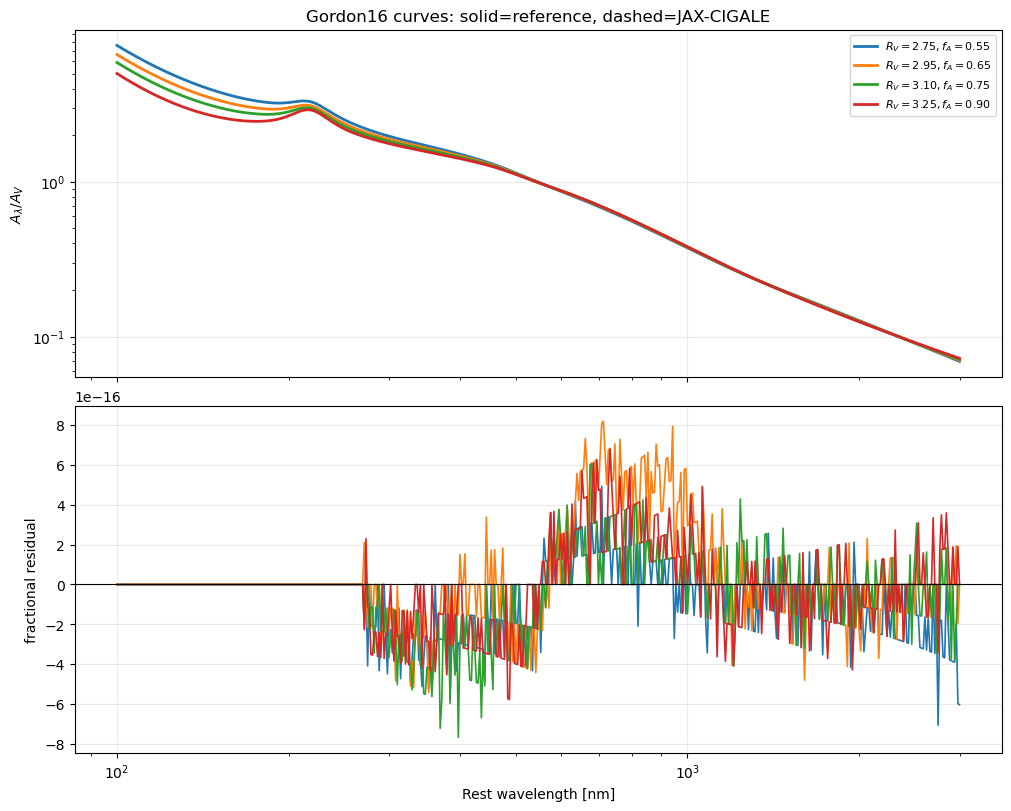

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
for item in parameter_grid:
    rv = item["R_V"]
    f_a = item["f_A"]
    label = fr"$R_V={rv:.2f}, f_A={f_a:.2f}$"
    expected = reference_gordon16_a_over_av(wave_a, rv, f_a)
    got = np.asarray(_gordon16_rvfa_a_over_av(jnp.asarray(wave_a), rv=jnp.asarray(rv), f_a=jnp.asarray(f_a)))
    rel_diff = (got - expected) / np.maximum(np.abs(expected), 1.0e-12)
    axes[0].plot(wave_nm, expected, lw=2.0, label=label)
    axes[0].plot(wave_nm, got, lw=0.9, ls="--", color=axes[0].lines[-1].get_color())
    axes[1].plot(wave_nm, rel_diff, lw=1.2)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$A_\lambda / A_V$")
axes[0].set_title("Gordon16 curves: solid=reference, dashed=JAX-CIGALE")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Rest wavelength [nm]")
axes[1].set_ylabel("fractional residual")
axes[1].grid(alpha=0.25)

curve_plot_path = OUTPUT_DIR / "gordon16_reference_comparison_curves.png"
fig.savefig(curve_plot_path, dpi=180)
print("saved", curve_plot_path)
plt.show()


## 5. Transmission and Monotonicity Checks

For a fixed curve, increasing `A_V` must only decrease flux. At V band, `A_lambda / A_V` should be approximately one by construction.


saved /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/validation_gordon16_dust/gordon16_transmission_monotonicity.png


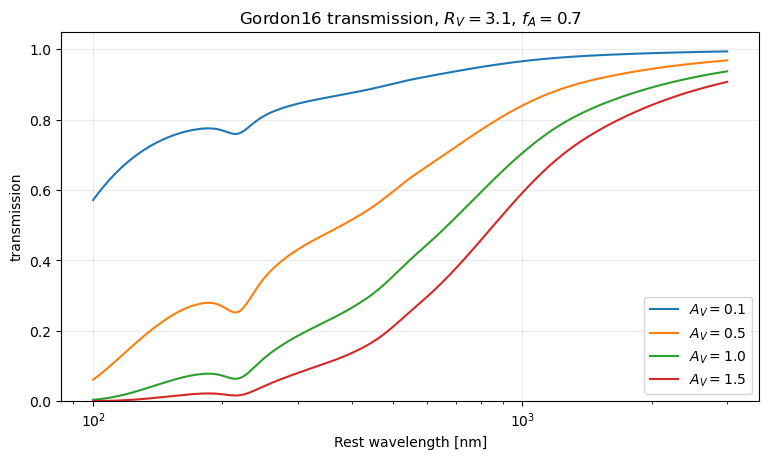

A(lambda)/A(V) nearest V band: 0.9865097192864853 at wavelength 5495.484047063162
{'A_V': 0.1, 'min_transmission': 0.5713484190118314, 'max_transmission': 0.9935102340664309}
{'A_V': 0.5, 'min_transmission': 0.06088427653877832, 'max_transmission': 0.9679696165098689}
{'A_V': 1.0, 'min_transmission': 0.003706895129650432, 'max_transmission': 0.9369651784862628}
{'A_V': 1.5, 'min_transmission': 0.0002256916281738874, 'max_transmission': 0.9069538245024487}
monotonic with A_V: True


In [5]:
transmission_rows = []
selected = {"R_V": 3.10, "f_A": 0.70}
curve = np.asarray(_gordon16_rvfa_a_over_av(
    jnp.asarray(wave_a),
    rv=jnp.asarray(selected["R_V"]),
    f_a=jnp.asarray(selected["f_A"]),
))

fig, ax = plt.subplots(figsize=(9, 4.8))
for av in [0.1, 0.5, 1.0, 1.5]:
    transmission = 10.0 ** (-0.4 * av * curve)
    transmission_rows.append({
        "A_V": av,
        "min_transmission": float(np.min(transmission)),
        "max_transmission": float(np.max(transmission)),
    })
    ax.plot(wave_nm, transmission, label=fr"$A_V={av:.1f}$")

ax.set_xscale("log")
ax.set_xlabel("Rest wavelength [nm]")
ax.set_ylabel("transmission")
ax.set_ylim(0.0, 1.05)
ax.set_title(fr"Gordon16 transmission, $R_V={selected['R_V']}$, $f_A={selected['f_A']}$")
ax.grid(alpha=0.25)
ax.legend()
transmission_plot_path = OUTPUT_DIR / "gordon16_transmission_monotonicity.png"
fig.savefig(transmission_plot_path, dpi=180)
print("saved", transmission_plot_path)
plt.show()

v_index = int(np.argmin(np.abs(wave_a - 5500.0)))
print("A(lambda)/A(V) nearest V band:", curve[v_index], "at wavelength", wave_a[v_index])
for row in transmission_rows:
    print(row)

transmission_stack = np.asarray([10.0 ** (-0.4 * av * curve) for av in [0.1, 0.5, 1.0, 1.5]])
monotonic_pass = bool(np.all(np.diff(transmission_stack, axis=0) <= 1.0e-12))
print("monotonic with A_V:", monotonic_pass)


## 6. Gradient Check

The differentiable backend needs finite gradients through `R_V` and `f_A` for NUTS. This cell checks a scalar summary of the curve, not a galaxy fit.


In [6]:
wave_grad = jnp.asarray(np.geomspace(1100.0, 25000.0, 128))


def scalar_curve_metric(theta):
    rv, f_a = theta
    curve = _gordon16_rvfa_a_over_av(wave_grad, rv=rv, f_a=f_a)
    return jnp.mean(jnp.log(curve + 1.0e-12))

grad = jax.grad(scalar_curve_metric)(jnp.asarray([3.05, 0.72]))
grad_np = np.asarray(grad)
print("gradient d metric / d(R_V, f_A):", grad_np)
print("finite gradient:", np.all(np.isfinite(grad_np)))


gradient d metric / d(R_V, f_A): [-0.10924132 -0.11424098]
finite gradient: True


## 7. Save Audit Metrics

The JSON file contains the comparison tolerances and a small pass/fail summary. The plots saved above are intended for visual audit.


In [7]:
metrics = {
    "jax_backend": jax.default_backend(),
    "jax_devices": [str(device) for device in jax.devices()],
    "jax_default_float_dtype": str(np.asarray(jnp.asarray(1.0)).dtype),
    "wavelength_range_angstrom": [float(wave_a.min()), float(wave_a.max())],
    "parameter_grid": comparison_rows,
    "max_abs_diff": float(max_abs_diff),
    "max_rel_diff": float(max_rel_diff),
    "transmission_rows": transmission_rows,
    "a_over_av_near_v_band": float(curve[v_index]),
    "v_band_wavelength_angstrom": float(wave_a[v_index]),
    "monotonic_with_av": monotonic_pass,
    "gradient": grad_np.tolist(),
    "gradient_finite": bool(np.all(np.isfinite(grad_np))),
    "pass": bool(max_abs_diff < 1.0e-5 and max_rel_diff < 1.0e-5 and monotonic_pass and np.all(np.isfinite(grad_np))),
}

metrics_path = OUTPUT_DIR / "gordon16_validation_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2) + "\n")
print("saved", metrics_path)
print("PASS:", metrics["pass"])


saved /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/validation_gordon16_dust/gordon16_validation_metrics.json
PASS: True


## 8. Checklist

- **Data entering:** a fixed rest-frame wavelength grid and a hand-picked grid of `(R_V, f_A)` dust parameters.
- **Transformations:** reference BEAST equations and JAX-CIGALE equations independently compute `A_lambda / A_V`.
- **Units:** wavelength is Angstrom internally; plots label wavelength in nm.
- **Masks/cuts:** none; wavelengths are clipped to the Gordon16 component-law support `0.3 <= 1/lambda[um] <= 10`, matching the JAX implementation.
- **Normalization:** curves are normalized as `A_lambda / A_V`; transmission is `10**(-0.4 * A_V * A_lambda/A_V)`.
- **Final quantity:** numerical agreement between independent reference and JAX-CIGALE curve, plus transmission and gradient sanity checks.
- **Most important cells to check:** the independent reference functions in Section 2 and the comparison loop in Section 3.
- **Limiting cases:** `f_A=1` is Fitzpatrick99; `f_A=0` is SMC Bar; increasing `A_V` must monotonically decrease transmission.
